# Bayesian Credal Sets

In [ ]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from scipy.special import digamma, gammaln
from sklearn.decomposition import PCA
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import scipy.stats
from numpy.random import default_rng
from matplotlib.patches import Ellipse as MEllipse
import warnings
import json as json_lib
from pathlib import Path
warnings.filterwarnings('ignore')
np.random.seed(42)

## Daten laden
Daten aus Garces Arias et al. (2025) -> https://github.com/EstebanGarces/human_drift/tree/main/drift_analysis

-> Jede Zeile ist ein Prompt × Modell × Decoding-Strategie mit drei Diversity-Werten: semantic, lexical, syntactic


In [21]:
DATA_DIR = Path('../human_drift/drift_analysis')

# Lade per_input_distances.json
# Struktur: {source: {task: {metric: [wert_pro_input, ...]}}}
# z.B. data['human']['storytelling']['semantic'] = [0.45, 0.38, ...] (100 Werte)

try:
    with open(DATA_DIR / 'per_input_distances.json') as f:
        per_input = json_lib.load(f)
    print('Geladen!')

except Exception as e:
    print(f'Fehler: {e}')
    per_input = None

# Überblick über die Datenstruktur
if per_input is not None:
    print(f'Oberste Keys: {list(per_input.keys())}')

    # Zweite Ebene zeigen
    first_key = list(per_input.keys())[0]
    print(f'Sub-Keys von "{first_key}": {list(per_input[first_key].keys())}')

    # Dritte Ebene zeigen
    second_key = list(per_input[first_key].keys())[0]
    print(f'Sub-Keys von "{second_key}": {list(per_input[first_key][second_key].keys())}')

    # Beispielwerte
    third_key = list(per_input[first_key][second_key].keys())[0]
    vals = per_input[first_key][second_key][third_key]
    print(f'Beispiel [{first_key}][{second_key}][{third_key}]: '
          f'{len(vals)} Werte, erste 5: {vals[:5]}')

Geladen!
Oberste Keys: ['human', 'llama', 'mistral', 'qwen', 'gemma']
Sub-Keys von "human": ['storytelling', 'translations']
Sub-Keys von "storytelling": ['semantic', 'lexical', 'syntactic']
Beispiel [human][storytelling][semantic]: 100 Werte, erste 5: [0.6367672204971313, 0.7101691921552022, 0.6397291660308838, 0.6779114339086745, 0.7116553147633871]


## Datenaufbereitung

Spaltennamen anpassen und Diversity-Spalten identifizieren


In [23]:
# Struktur von per_input_distances.json analysieren
# Struktur:
# {
#   'human':  {'storytelling': {'semantic': [...], 'lexical': [...], 'syntactic': [...]},
#              'translation':  {'semantic': [...], 'lexical': [...], 'syntactic': [...]}},
#   'llama':  {...},
#   'mistral': {...}, ...
# }

print('=== STRUKTUR ===')
sources = list(per_input.keys())
print(f'Sources ({len(sources)}): {sources}')
print()

# Für jede Source und Task die verfügbaren Metriken und Anzahl der Inputs anzeigen
for source in sources:
    tasks = list(per_input[source].keys())
    for task in tasks:
        metrics = list(per_input[source][task].keys())
        n = len(per_input[source][task][metrics[0]])
        print(f'  {source:8s} | {task:12s} | Metriken: {metrics} | n={n} Inputs')

=== STRUKTUR ===
Sources (5): ['human', 'llama', 'mistral', 'qwen', 'gemma']

  human    | storytelling | Metriken: ['semantic', 'lexical', 'syntactic'] | n=100 Inputs
  human    | translations | Metriken: ['semantic', 'lexical', 'syntactic'] | n=500 Inputs
  llama    | storytelling | Metriken: ['semantic', 'lexical', 'syntactic'] | n=100 Inputs
  llama    | translations | Metriken: ['semantic', 'lexical', 'syntactic'] | n=500 Inputs
  mistral  | storytelling | Metriken: ['semantic', 'lexical', 'syntactic'] | n=100 Inputs
  mistral  | translations | Metriken: ['semantic', 'lexical', 'syntactic'] | n=500 Inputs
  qwen     | storytelling | Metriken: ['semantic', 'lexical', 'syntactic'] | n=100 Inputs
  qwen     | translations | Metriken: ['semantic', 'lexical', 'syntactic'] | n=499 Inputs
  gemma    | storytelling | Metriken: ['semantic', 'lexical', 'syntactic'] | n=100 Inputs
  gemma    | translations | Metriken: ['semantic', 'lexical', 'syntactic'] | n=500 Inputs


In [ ]:
# Variablen für spätere Zellen
METRIC_COLS = None
K_DIM = 3  # semantic, lexical, syntactic

# Wertebereiche pro Metrik
print('=== WERTEBEREICHE PRO METRIK ===')
for source in list(per_input.keys())[:2]:
    for task in per_input[source]:
        for metric in per_input[source][task]:
            vals = np.array(per_input[source][task][metric])
            print(f'  {source:8s} {task:12s} {metric:10s}: '
                    f'mean={vals.mean():.3f} std={vals.std():.3f} '
                    f'min={vals.min():.3f} max={vals.max():.3f}')

=== WERTEBEREICHE PRO METRIK ===
  human    storytelling semantic  : mean=0.666 std=0.070 min=0.410 max=0.791
  human    storytelling lexical   : mean=0.985 std=0.004 min=0.967 max=0.995
  human    storytelling syntactic : mean=0.805 std=0.016 min=0.757 max=0.849
  human    translations semantic  : mean=0.073 std=0.047 min=0.000 max=0.274
  human    translations lexical   : mean=0.734 std=0.136 min=0.000 max=0.982
  human    translations syntactic : mean=0.579 std=0.159 min=0.000 max=0.892
  llama    storytelling semantic  : mean=0.352 std=0.096 min=0.150 max=0.585
  llama    storytelling lexical   : mean=0.937 std=0.018 min=0.861 max=0.973
  llama    storytelling syntactic : mean=0.692 std=0.032 min=0.599 max=0.826
  llama    translations semantic  : mean=0.055 std=0.045 min=-0.000 max=0.229
  llama    translations lexical   : mean=0.586 std=0.176 min=0.000 max=0.938
  llama    translations syntactic : mean=0.400 std=0.188 min=0.000 max=0.830


## Dirichlet-Modell auf dem Metrik-Simplex

`semantic`, `lexical` und `syntactic` - Werte werden pro Prompt als Komposition interpretiert und auf den 3-dimensionalen Simplex normiert  
-> einheitliches probabilistisches Modell

```
p(x) ~ Dirichlet(alpha_source,task) mit x = [semantic, lexical, syntactic]
alpha ~ LogNormal(0, 1.5)
```

posteriore Mittelwert `alpha / alpha.sum()`: erwarteter Anteil der jeweiligen Metrik an Diversity-Komposition


In [ ]:
METRICS = ['semantic', 'lexical', 'syntactic']
K_DIM = len(METRICS)
SIMPLEX_EPS = 1e-6

def metric_simplex_points(source, task, eps=SIMPLEX_EPS):
    """Normiert semantic/lexical/syntactic pro Prompt auf den Simplex"""
    vals = np.vstack([
        np.asarray(per_input[source][task][metric], dtype=float)
        for metric in METRICS
    ]).T

    vals = np.clip(vals, 0.0, None) + eps
    return vals / vals.sum(axis=1, keepdims=True)


def posterior_mean_composition(trace):
    """Posterior-Samples für E[x | alpha] = alpha / sum(alpha)"""
    alpha = trace.posterior['alpha'].values.reshape(-1, K_DIM)

    return alpha / alpha.sum(axis=1, keepdims=True)


def sample_dirichlet_predictive(trace, n_samples=800, seed=42):
    """Posterior-prädiktive Simplex-Samples aus dem Dirichlet-Modell"""
    rng = default_rng(seed)
    alpha = trace.posterior['alpha'].values.reshape(-1, K_DIM)
    idx = rng.choice(len(alpha), size=min(n_samples, len(alpha)), replace=False)

    return np.array([rng.dirichlet(alpha[i]) for i in idx])



dirichlet_posteriors = {}  # Key: (source, task)

# Dirichlet-Modelle pro Source/Task fitten
for source in per_input:
    for task in per_input[source]:
        simplex_vals = metric_simplex_points(source, task)
        print(f'Fitte Dirichlet-Modell: {source:8s} | {task:12s} | {simplex_vals.shape[0]} Inputs')

        with pm.Model():
            # Log-Alpha-Parameter mit Normal-Prior (auf Log-Skala, damit Alpha > 0)
            log_alpha = pm.Normal('log_alpha', mu=0.0, sigma=1.5, shape=K_DIM)
            alpha = pm.Deterministic('alpha', pt.exp(log_alpha))
            pm.Dirichlet('obs', a=alpha, observed=simplex_vals)
            trace = pm.sample(
                500, tune=300, chains=2,
                progressbar=False,
                return_inferencedata=True,
                target_accept=0.9
            )

        dirichlet_posteriors[(source, task)] = trace

# Überprüfe Konvergenz mit R-hat
# R-hat > 1.05 deutet auf mögliche Konvergenzprobleme hin
bad = []
for key, trace in dirichlet_posteriors.items():
    rhat = az.rhat(trace, var_names=['log_alpha'])['log_alpha']
    if float(rhat.max()) > 1.05:
        bad.append(key)
print(f'R-hat > 1.05: {len(bad)} Gruppen')


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_alpha]


Fitte Dirichlet-Modell: human    | storytelling | 100 Inputs


Sampling 2 chains for 300 tune and 500 draw iterations (600 + 1_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_alpha]


Fitte Dirichlet-Modell: human    | translations | 500 Inputs


Sampling 2 chains for 300 tune and 500 draw iterations (600 + 1_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_alpha]


...

Fitte Dirichlet-Modell: gemma    | storytelling | 100 Inputs


Sampling 2 chains for 300 tune and 500 draw iterations (600 + 1_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [log_alpha]


Fitte Dirichlet-Modell: gemma    | translations | 500 Inputs


Sampling 2 chains for 300 tune and 500 draw iterations (600 + 1_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat > 1.05: 0 Gruppen


## Posteriore Drift-Analyse (Story → Translation)

Drift pro Source und Metrik = Differenz der posterioren Dirichlet-Mittelwerte:

```
Drift_metric = E[x_metric | alpha_story] - E[x_metric | alpha_translation]
```

-> Wenn ein Anteil steigt, müssen die anderen Anteile entsprechend fallen


In [26]:
sources = ['human', 'llama', 'mistral', 'qwen', 'gemma']
SOURCE_COLORS = {
    'human':   '#1565C0',
    'llama':   '#E65100',
    'mistral': '#6A1B9A',
    'qwen':    '#2E7D32',
    'gemma':   '#B71C1C',
}

drift_results = {}  # (source, metric) -> array von Drift-Samples

print('=' * 58)
print('DRIFT Story -> Translation (Dirichlet-Mittelwert-Differenz)')
print('Positiv = Metrik-Anteil ist im Storytelling groesser')
print('=' * 58)

# Berechne Drift (Storytelling - Translation) pro Source und Metrik
for metric_idx, metric in enumerate(METRICS):
    print(f'\n--- {metric} ---')
    for src in sources:
        t_s = dirichlet_posteriors.get((src, 'storytelling'))
        t_t = dirichlet_posteriors.get((src, 'translations'))
        if t_s is None or t_t is None:
            continue
        mu_story = posterior_mean_composition(t_s)[:, metric_idx]
        mu_trans = posterior_mean_composition(t_t)[:, metric_idx]
        n = min(len(mu_story), len(mu_trans))
        drift = mu_story[:n] - mu_trans[:n]
        drift_results[(src, metric)] = drift
        hdi = az.hdi(drift, hdi_prob=0.94)
        print(f'  {src:8s}: Median={np.median(drift):+.4f}  '
              f'94% HDI=[{hdi[0]:+.4f}, {hdi[1]:+.4f}]')

print()
print('--- Wahrscheinlichkeitsaussagen ---')
for metric in METRICS:
    for src in [s for s in sources if s != 'human']:
        if ('human', metric) in drift_results and (src, metric) in drift_results:
            p = np.mean(
                np.abs(drift_results[('human', metric)]) >
                np.abs(drift_results[(src, metric)])
            )
            if p > 0.8:
                print(f'  P(|Human-Drift| > |{src}-Drift| | {metric}) = {p:.3f}')


DRIFT Story -> Translation (Dirichlet-Mittelwert-Differenz)
Positiv = Metrik-Anteil ist im Storytelling groesser

--- semantic ---
  human   : Median=+0.2155  94% HDI=[+0.2114, +0.2196]
  llama   : Median=+0.0644  94% HDI=[+0.0542, +0.0750]
  mistral : Median=+0.0659  94% HDI=[+0.0587, +0.0740]
  qwen    : Median=+0.0492  94% HDI=[+0.0382, +0.0597]
  gemma   : Median=+0.0531  94% HDI=[+0.0422, +0.0641]

--- lexical ---
  human   : Median=-0.1372  94% HDI=[-0.1448, -0.1299]
  llama   : Median=-0.1260  94% HDI=[-0.1431, -0.1092]
  mistral : Median=-0.0808  94% HDI=[-0.0939, -0.0664]
  qwen    : Median=-0.1366  94% HDI=[-0.1546, -0.1192]
  gemma   : Median=-0.1401  94% HDI=[-0.1569, -0.1210]

--- syntactic ---
  human   : Median=-0.0780  94% HDI=[-0.0855, -0.0713]
  llama   : Median=+0.0618  94% HDI=[+0.0456, +0.0764]
  mistral : Median=+0.0150  94% HDI=[+0.0005, +0.0272]
  qwen    : Median=+0.0872  94% HDI=[+0.0730, +0.1040]
  gemma   : Median=+0.0867  94% HDI=[+0.0704, +0.1028]

--- Wah

## Kalibrierung (Modell vs. Human)

Wie ähnlich ist jedes Modell dem Menschen im Dirichlet-Simplex?

Maß pro Metrik und Task: absolute Differenz der posterioren Dirichlet-Mittelwerte  
Kleiner bedeutet näher an der menschlichen Diversity-Komposition


In [ ]:
calib_results = {}  # (source, task, metric) -> array

print('=' * 58)
print('KALIBRIERUNG |Dirichlet-Mittelwert_modell - human|')
print('Kleiner = aehnlicher zum Menschen')
print('=' * 58)

# Berechne Kalibrierung (Abstand zum Human-Dirichlet-Mittelwert) pro Source, Task und Metrik
for task, task_short in [('storytelling','Story'), ('translations','Trans')]:
    print(f'\n--- {task_short} ---')
    t_human = dirichlet_posteriors.get(('human', task))
    if t_human is None:
        continue
    mu_human_all = posterior_mean_composition(t_human)

    for metric_idx, metric in enumerate(METRICS):
        print(f'  {metric}:')
        mu_human = mu_human_all[:, metric_idx]
        row = []
        for src in [s for s in sources if s != 'human']:
            t_mod = dirichlet_posteriors.get((src, task))
            if t_mod is None:
                continue
            mu_mod = posterior_mean_composition(t_mod)[:, metric_idx]
            n = min(len(mu_human), len(mu_mod))
            diff = np.abs(mu_mod[:n] - mu_human[:n])
            calib_results[(src, task, metric)] = diff
            hdi = az.hdi(diff, hdi_prob=0.94)
            row.append((src, np.median(diff)))
            print(f'    {src:8s}: {np.median(diff):.4f}  '
                  f'HDI=[{hdi[0]:.4f}, {hdi[1]:.4f}]')
        row.sort(key=lambda x: x[1])
        print(f'    Ranking: {" > ".join(s for s,_ in row)}')


KALIBRIERUNG |Dirichlet-Mittelwert_modell - human|
Kleiner = aehnlicher zum Menschen

--- Story ---
  semantic:
    llama   : 0.0970  HDI=[0.0907, 0.1024]
    mistral : 0.1244  HDI=[0.1187, 0.1311]
    qwen    : 0.1023  HDI=[0.0959, 0.1080]
    gemma   : 0.1009  HDI=[0.0950, 0.1069]
    Ranking: llama > gemma > qwen > mistral
  lexical:
    llama   : 0.0737  HDI=[0.0667, 0.0807]
    mistral : 0.0952  HDI=[0.0873, 0.1037]
    qwen    : 0.0779  HDI=[0.0706, 0.0867]
    gemma   : 0.0825  HDI=[0.0751, 0.0895]
    Ranking: llama > qwen > gemma > mistral
  syntactic:
    llama   : 0.0234  HDI=[0.0162, 0.0302]
    mistral : 0.0292  HDI=[0.0214, 0.0375]
    qwen    : 0.0243  HDI=[0.0168, 0.0316]
    gemma   : 0.0185  HDI=[0.0119, 0.0253]
    Ranking: gemma > llama > qwen > mistral

--- Trans ---
  semantic:
    llama   : 0.0538  HDI=[0.0449, 0.0632]
    mistral : 0.0248  HDI=[0.0184, 0.0316]
    qwen    : 0.0639  HDI=[0.0555, 0.0744]
    gemma   : 0.0617  HDI=[0.0520, 0.0719]
    Ranking: mist

## Visualisierung

Links: Drift pro Source und Metrikanteil.  
Rechts: Kalibrierung Modell vs. Human pro Metrikanteil.  
Fehlerbalken = 94% posteriores HDI.


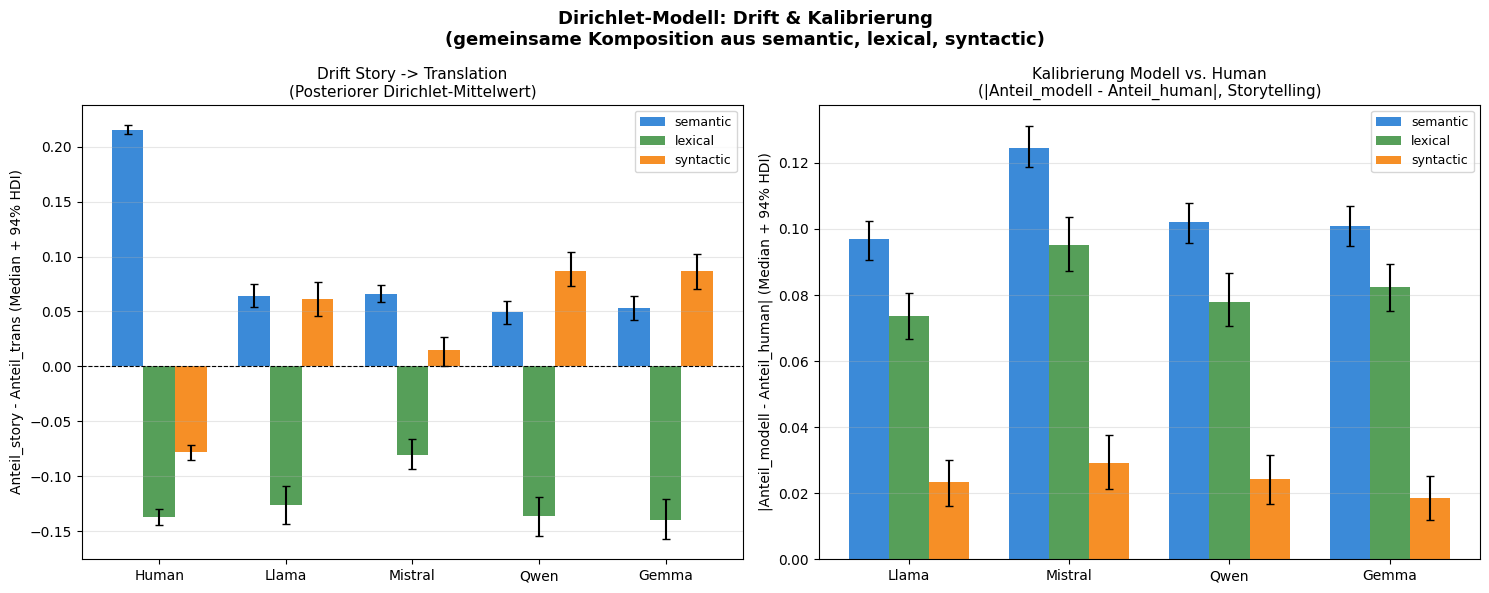

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Dirichlet-Modell: Drift & Kalibrierung\n'
             '(gemeinsame Komposition aus semantic, lexical, syntactic)',
             fontsize=13, fontweight='bold')

metric_colors = {
    'semantic':  '#1976D2',
    'lexical':   '#388E3C',
    'syntactic': '#F57C00',
}

ax = axes[0]
ax.set_title('Drift Story -> Translation\n'
             '(Posteriorer Dirichlet-Mittelwert)', fontsize=11)
n_src = len(sources)
n_met = len(METRICS)
width = 0.25
x = np.arange(n_src)

for j, metric in enumerate(METRICS):
    medians = [np.median(drift_results.get((src, metric), [0]))
               for src in sources]
    hdis = [az.hdi(drift_results.get((src, metric),
            np.array([0, 0])), hdi_prob=0.94) for src in sources]
    errs = [[medians[k] - hdis[k][0] for k in range(n_src)],
            [hdis[k][1] - medians[k] for k in range(n_src)]]
    ax.bar(x + j*width, medians, width,
           color=metric_colors[metric], alpha=0.85, label=metric)
    ax.errorbar(x + j*width, medians, yerr=errs,
                fmt='none', color='black', capsize=3, lw=1.5)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(x + width)
ax.set_xticklabels([s.capitalize() for s in sources], fontsize=10)
ax.set_ylabel('Anteil_story - Anteil_trans (Median + 94% HDI)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
ax.set_title('Kalibrierung Modell vs. Human\n'
             '(|Anteil_modell - Anteil_human|, Storytelling)', fontsize=11)
model_sources = [s for s in sources if s != 'human']
x2 = np.arange(len(model_sources))

for j, metric in enumerate(METRICS):
    medians = [np.median(calib_results.get((src, 'storytelling', metric),
               np.array([0]))) for src in model_sources]
    hdis = [az.hdi(calib_results.get((src, 'storytelling', metric),
            np.array([0, 0])), hdi_prob=0.94) for src in model_sources]
    errs = [[medians[k] - hdis[k][0] for k in range(len(model_sources))],
            [hdis[k][1] - medians[k] for k in range(len(model_sources))]]
    ax.bar(x2 + j*width, medians, width,
           color=metric_colors[metric], alpha=0.85, label=metric)
    ax.errorbar(x2 + j*width, medians, yerr=errs,
                fmt='none', color='black', capsize=3, lw=1.5)

ax.set_xticks(x2 + width)
ax.set_xticklabels([s.capitalize() for s in model_sources], fontsize=10)
ax.set_ylabel('|Anteil_modell - Anteil_human| (Median + 94% HDI)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dirichlet_drift_calibration.png', dpi=150, bbox_inches='tight')
plt.show()


## Dirichlet-Posterior-Predictive vs. empirische Komposition

Pro Metrikanteil und Task: Wie gut deckt die geschätzte Dirichlet-Verteilung die
beobachteten Simplex-Kompositionen ab?

- **Balken** = empirische normierte Metrikanteile
- **Linie** = posterior-prädiktive Dirichlet-Dichte als Histogramm-Median
- **Band** = 94% posterior-prädiktives Intervall der Histogrammdichte


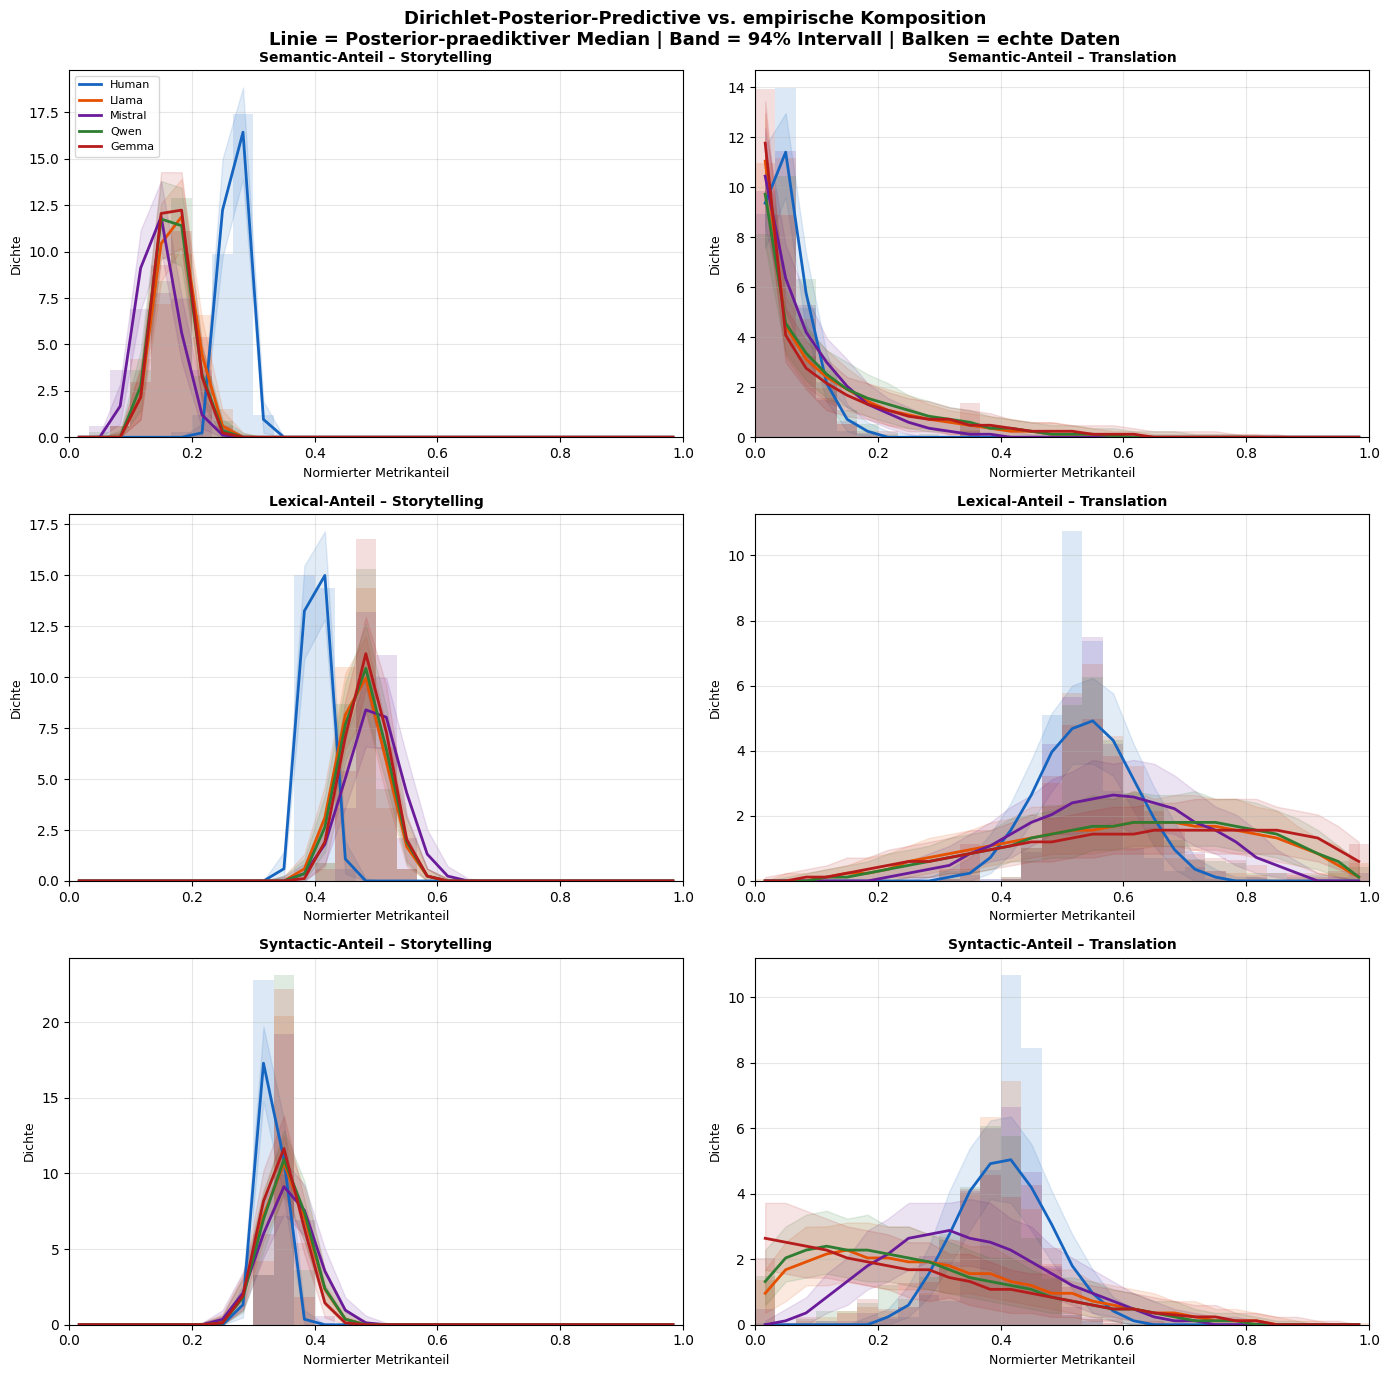

Jede Zeile = eine Metrik-Komponente des gemeinsamen Dirichlet-Modells
Linie = Posterior-praediktiver Median der Komponentendichte
Band  = 94% posterior-praediktives Intervall
Balken = echte Daten nach Simplex-Normierung


In [ ]:
x_grid = np.linspace(0, 1, 31)
x_centers = 0.5 * (x_grid[:-1] + x_grid[1:])

def posterior_predictive_histograms(trace, metric_idx, bins=x_grid, n_rep=300, seed=42):
    rng = default_rng(seed)
    alpha = trace.posterior['alpha'].values.reshape(-1, K_DIM)
    idx = rng.choice(len(alpha), size=min(n_rep, len(alpha)), replace=False)
    densities = []
    for i in idx:
        draws = rng.dirichlet(alpha[i], size=250)[:, metric_idx]
        density, _ = np.histogram(draws, bins=bins, density=True)
        densities.append(density)
    return np.asarray(densities)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle(
    'Dirichlet-Posterior-Predictive vs. empirische Komposition\n'
    'Linie = Posterior-praediktiver Median | Band = 94% Intervall | Balken = echte Daten',
    fontsize=13, fontweight='bold'
)

task_map = [('storytelling', 'Storytelling'), ('translations', 'Translation')]

for row, metric in enumerate(METRICS):
    for col, (task, task_label) in enumerate(task_map):
        ax = axes[row, col]
        ax.set_title(f'{metric.capitalize()}-Anteil – {task_label}',
                     fontsize=10, fontweight='bold')

        metric_idx = METRICS.index(metric)
        for source in per_input:
            c = SOURCE_COLORS.get(source, 'gray')
            trace = dirichlet_posteriors.get((source, task))
            if trace is None:
                continue

            vals = metric_simplex_points(source, task)[:, metric_idx]
            ax.hist(vals, bins=x_grid, density=True,
                    color=c, alpha=0.15, edgecolor='none')

            densities = posterior_predictive_histograms(
                trace,
                metric_idx,
                seed=abs(hash((source, task, metric))) % (2**32)
            )
            median_density = np.median(densities, axis=0)
            lo_density = np.percentile(densities, 3, axis=0)
            hi_density = np.percentile(densities, 97, axis=0)

            ax.plot(x_centers, median_density,
                    color=c, lw=2,
                    label=source.capitalize())
            ax.fill_between(x_centers, lo_density, hi_density,
                            color=c, alpha=0.12)

        ax.set_xlabel('Normierter Metrikanteil', fontsize=9)
        ax.set_ylabel('Dichte', fontsize=9)
        ax.set_xlim(0, 1)
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('dirichlet_posterior_predictive_per_metric.png', dpi=150, bbox_inches='tight')
plt.show()


## Bayesianische Credal Sets im PCA-Raum

- gestrichelten Linien = empirischen konvexen Hüllen wie im Paper
- durchgezogenen Ellipsen = posterior-prädiktiven Dirichlet-Samples der gebinnten Pairwise-Distances:

```text
counts_key -> Dirichlet(counts_key + alpha_prior) -> posterior-predictive Histogramme -> PCA -> 95%-Ellipse
```


Lade pairwise_distances.json ...
Geladen!
  PCA (story, semantic  ): PC1=74.5% PC2=20.0% sign=(1, 1)
  PCA (story, lexical   ): PC1=60.3% PC2=28.9% sign=(1, 1)
  PCA (story, syntactic ): PC1=61.1% PC2=22.4% sign=(1, 1)
  PCA (trans, semantic  ): PC1=26.9% PC2=17.9% sign=(-1, 1)
  PCA (trans, lexical   ): PC1=27.7% PC2=17.4% sign=(-1, -1)
  PCA (trans, syntactic ): PC1=46.8% PC2=15.8% sign=(-1, 1)


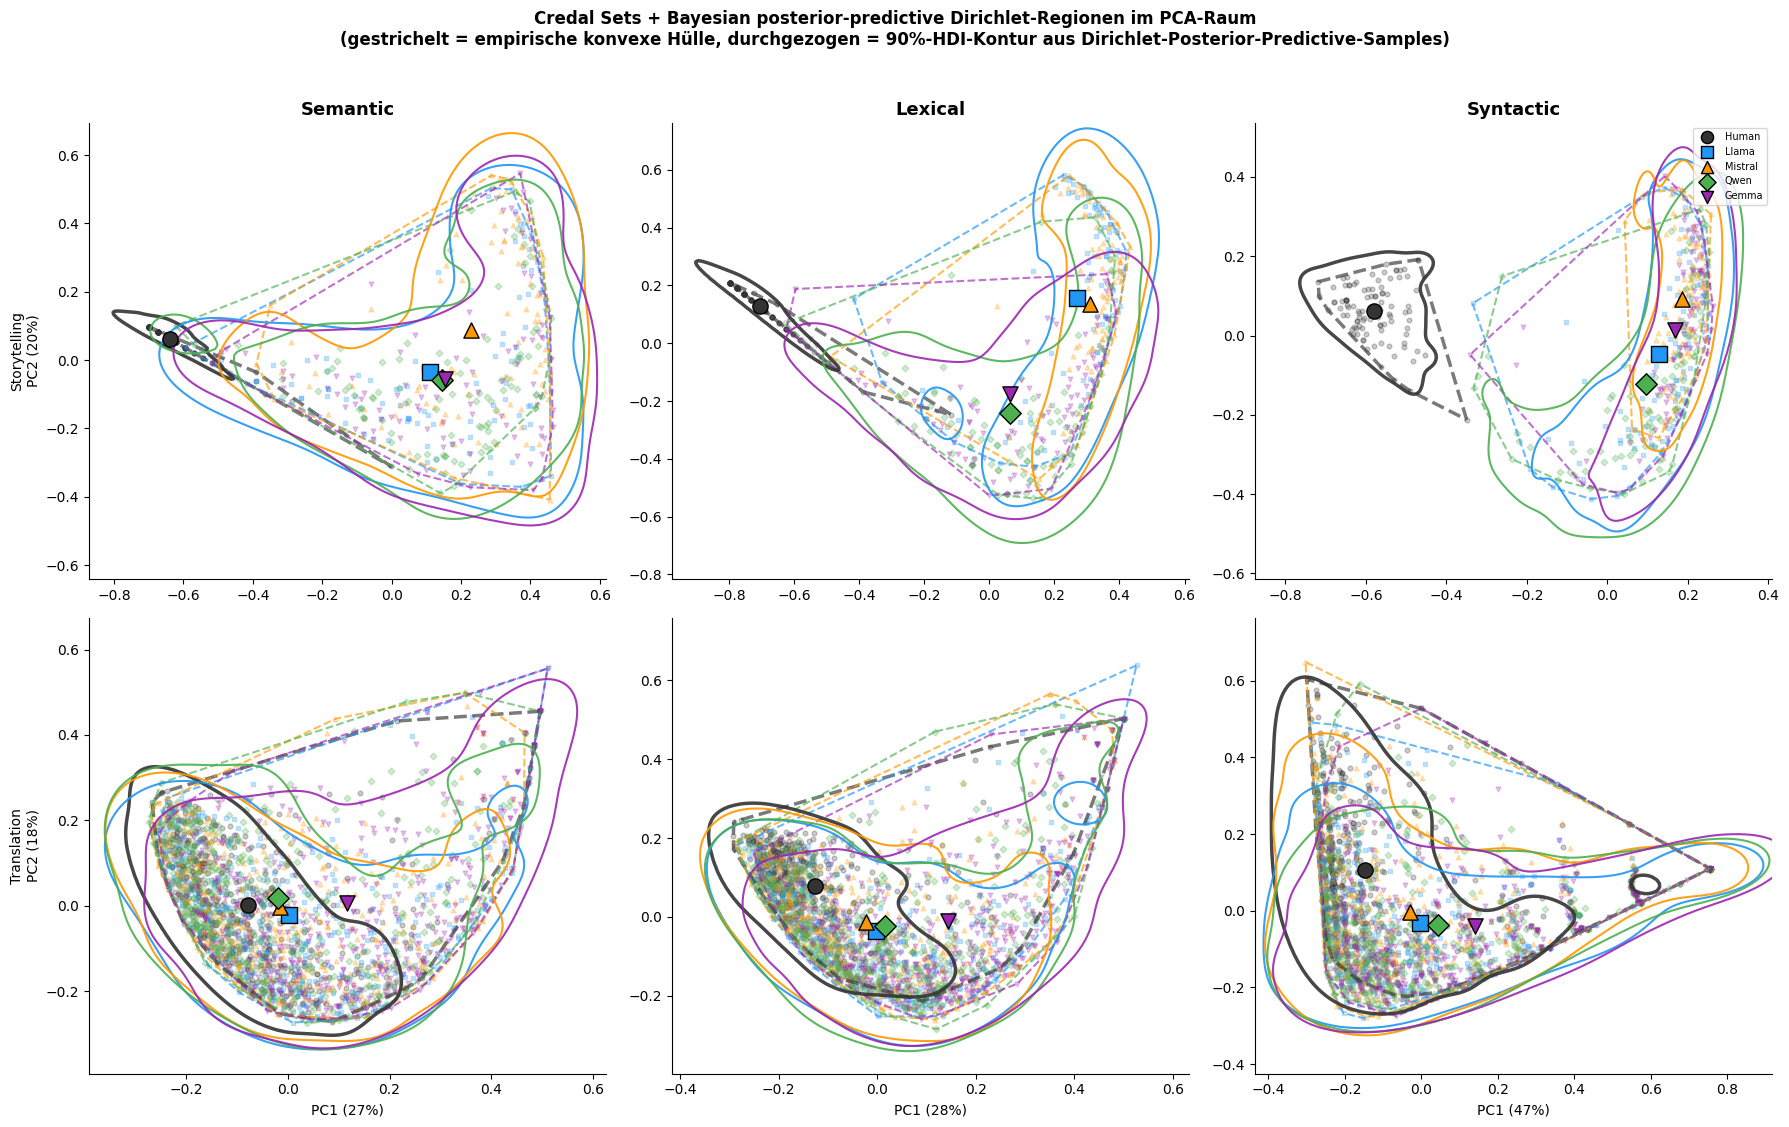

In [32]:
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import json as _json
from scipy.spatial import ConvexHull

SOURCES_PW = ['human', 'llama', 'mistral', 'qwen', 'gemma']
TASKS_PW   = ['storytelling', 'translations']
K_BINS     = 15
LAPLACE_A  = 0.1
DEGEN_THR  = 1e-6
N_POSTERIOR_PREDICTIVE = 800  # posterior-predictive histogram samples per source/task/metric

# Paper-Farben und Marker
PW_COLORS = {
    'human':   '#333333', 'llama':  '#2196F3',
    'mistral': '#FF9800', 'qwen':   '#4CAF50', 'gemma': '#9C27B0',
}
PW_MARKERS = {
    'human': 'o', 'llama': 's', 'mistral': '^', 'qwen': 'D', 'gemma': 'v',
}

# ── 1. Lade pairwise_distances.json ──────────────────────────────
print('Lade pairwise_distances.json ...')
with open(DATA_DIR / 'pairwise_distances.json') as f:
    pw = _json.load(f)
print('Geladen!')

# ── 2. Degeneracy-Filter ─────────────────────────────────────────
valid_keys = {}
for source in SOURCES_PW:
    for task in TASKS_PW:
        all_k = list(pw[source][task]['semantic'].keys())
        kept = []
        for key in all_k:
            max_d = 0.0
            for m in METRICS:
                dists = pw[source][task][m].get(key, [])
                if dists:
                    max_d = max(max_d, max(abs(d) for d in dists))
            if max_d > DEGEN_THR:
                kept.append(key)
        valid_keys[(source, task)] = kept

# ── 3. Rank-Transformation + uniforme Bins ───────────────────────
# Für jede Metrik werden alle Distanzen gepoolt und in Ränge [0,1] transformiert
pooled_metric_values = {}
for metric in METRICS:
    vals = []
    for source in SOURCES_PW:
        for task in TASKS_PW:
            for key in valid_keys[(source, task)]:
                vals.extend(pw[source][task][metric].get(key, []))
    pooled_metric_values[metric] = np.sort(np.array(vals, dtype=float))

rank_bin_edges = np.linspace(0.0, 1.0, K_BINS + 1)

def distance_counts_ranked(dists, metric):
    """Zählt pairwise distances nach metrikspezifischer Rank-Transformation in K_BINS"""
    dists = np.array(dists, dtype=float)
    pooled = pooled_metric_values[metric]
    ranks = np.searchsorted(pooled, dists, side='right') / len(pooled)
    counts, _ = np.histogram(ranks, bins=rank_bin_edges)
    return counts.astype(float)

def counts_to_simplex(counts, alpha=LAPLACE_A):
    """Laplace-geglättetes Histogramm als Wahrscheinlichkeitsvektor im Simplex"""
    probs = counts + alpha
    return probs / probs.sum()

# ── 4. Empirische Simplex-Punkte: ein Histogramm pro Input ───────
credal_full = {s: {t: {m: [] for m in METRICS} for t in TASKS_PW} for s in SOURCES_PW}
counts_full = {s: {t: {m: [] for m in METRICS} for t in TASKS_PW} for s in SOURCES_PW}

for s in SOURCES_PW:
    for t in TASKS_PW:
        for key in valid_keys[(s, t)]:
            for m in METRICS:
                dists = pw[s][t][m].get(key, [])
                c = distance_counts_ranked(dists, m)
                counts_full[s][t][m].append(c)
                credal_full[s][t][m].append(counts_to_simplex(c, LAPLACE_A))

for s in SOURCES_PW:
    for t in TASKS_PW:
        for m in METRICS:
            counts_full[s][t][m] = np.array(counts_full[s][t][m])
            credal_full[s][t][m] = np.array(credal_full[s][t][m])

# ── 5. Affine-Hull-Projektion + PCA per (task, metric) ───────────
def project_to_affine_hull(points):
    centroid = points.mean(axis=0)
    centered = points - centroid
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    if S.size == 0:
        return np.zeros((points.shape[0], 1)), centroid, Vt[:1], 1
    tol = S[0] * max(points.shape) * np.finfo(float).eps
    rank = int(np.sum(S > tol))
    return centered @ Vt[:rank].T, centroid, Vt[:rank], rank

pca_models_pw = {}
projected_viz = {s: {t: {} for t in TASKS_PW} for s in SOURCES_PW}
affine_basis = {}
pca_signs = {}

# Für jede (task, metric) Kombination werden alle Simplex-Punkte über alle Quellen hinweg in den affinen Hull projiziert und dann PCA für 2D-Visualisierung angewendet
for task in TASKS_PW:
    for metric in METRICS:
        all_pts = np.vstack([credal_full[s][task][metric] for s in SOURCES_PW])

        proj_all, centroid, Vt, rank = project_to_affine_hull(all_pts)
        affine_basis[(task, metric)] = (centroid, Vt)

        pca = PCA(n_components=2, random_state=42)
        pca.fit(proj_all)
        pca_models_pw[(task, metric)] = pca

        idx = 0
        for s in SOURCES_PW:
            n = len(credal_full[s][task][metric])
            projected_viz[s][task][metric] = pca.transform(proj_all[idx:idx+n])
            idx += n

        # Human-Alignment: Human-Zentroid links/oben
        sign_x, sign_y = 1, 1
        human_centroid = projected_viz['human'][task][metric].mean(axis=0)
        if human_centroid[0] > 0:
            sign_x = -1
            for s in SOURCES_PW:
                projected_viz[s][task][metric][:, 0] *= -1

        human_centroid = projected_viz['human'][task][metric].mean(axis=0)
        if human_centroid[1] < 0:
            sign_y = -1
            for s in SOURCES_PW:
                projected_viz[s][task][metric][:, 1] *= -1

        pca_signs[(task, metric)] = np.array([sign_x, sign_y])

        var = pca.explained_variance_ratio_
        print(
            f'  PCA ({task[:5]}, {metric:10s}): '
            f'PC1={var[0]*100:.1f}% PC2={var[1]*100:.1f}% sign=({sign_x}, {sign_y})'
        )

# ── 6. Bayesianische posterior-predictive Region im PCA-Raum ─────
def posterior_predictive_binned_to_pca(source, task, metric,
                                       n_samples=N_POSTERIOR_PREDICTIVE,
                                       alpha_prior=LAPLACE_A,
                                       seed=42):
    """Bayesianische Hülle für binned pairwise distances

    Für jeden empirischen Input liegen Bin-Zählungen c vor. Mit Dirichlet-Multinomial-
    Konjugation pro Input den Posterior:

        theta_key | counts ~ Dirichlet(counts_key + alpha_prior)

    -> daraus posterior-predictive Histogramm-Wahrscheinlichkeiten theta
    Diese Samples durch dieselbe Affine-Hull/PCA-Pipeline projiziert wie die empirischen Credal-Set-Punkte
    """
    rng = default_rng(seed)
    counts = counts_full[source][task][metric]
    if len(counts) == 0:
        return np.empty((0, 2))

    sample_idx = rng.choice(len(counts), size=n_samples, replace=True)
    theta_samples = np.array([
        rng.dirichlet(counts[i] + alpha_prior)
        for i in sample_idx
    ])

    centroid, Vt = affine_basis[(task, metric)]
    proj = (theta_samples - centroid) @ Vt.T
    out = pca_models_pw[(task, metric)].transform(proj)
    out = out * pca_signs[(task, metric)]
    return out


def add_convex_hull(ax, pts_2d, color, lw=1.3, ls='--', alpha=0.7):
    """Empirisches Credal Set als konvexe Hülle im PCA-Raum"""
    if pts_2d is None or len(pts_2d) < 3:
        return
    try:
        hull = ConvexHull(pts_2d)
        verts = np.append(hull.vertices, hull.vertices[0])
        ax.plot(pts_2d[verts, 0], pts_2d[verts, 1],
                color=color, linewidth=lw, linestyle=ls,
                alpha=alpha, zorder=3)
    except Exception:
        return


def add_posterior_predictive_hdi_contour(
    ax, pts_2d, color,
    mass=0.95,
    gridsize=120,
    lw=2.0,
    alpha=0.9
):
    """
    Zeichnet eine posterior-prädiktive HDI-Kontur im PCA-Raum.

    -> zeigt den dichtesten Bereich, der ca. `mass` der posterior-prädiktiven Punkte enthält.
    """
    if pts_2d is None or len(pts_2d) < 10:
        return

    x = pts_2d[:, 0]
    y = pts_2d[:, 1]

    # KDE auf posterior-prädiktiven Samples
    values = np.vstack([x, y])
    kde = gaussian_kde(values)

    # Grid über den Bereich der Samples
    x_pad = 0.50 * (x.max() - x.min() + 1e-9)
    y_pad = 0.50 * (y.max() - y.min() + 1e-9)

    xx, yy = np.meshgrid(
        np.linspace(x.min() - x_pad, x.max() + x_pad, gridsize),
        np.linspace(y.min() - y_pad, y.max() + y_pad, gridsize)
    )

    grid = np.vstack([xx.ravel(), yy.ravel()])
    zz = kde(grid).reshape(xx.shape)

    # Dichteschwelle für HDI bestimmen:
    # Punkte mit höchster Dichte sammeln, bis mass erreicht ist.
    z_flat = zz.ravel()
    order = np.argsort(z_flat)[::-1]
    z_sorted = z_flat[order]
    cumsum = np.cumsum(z_sorted)
    cumsum = cumsum / cumsum[-1]

    level = z_sorted[np.searchsorted(cumsum, mass)]

    ax.contour(
        xx, yy, zz,
        levels=[level],
        colors=[color],
        linewidths=lw,
        alpha=alpha,
        zorder=4
    )

# ── 7. Plot: Empirische Hulls + Bayesian posterior-predictive Ellipsen ──
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

all_pts = np.vstack(all_pts)

for row, task in enumerate(TASKS_PW):
    for col, metric in enumerate(METRICS):
        ax = axes[row][col]
        pca_m = pca_models_pw[(task, metric)]
        ve = pca_m.explained_variance_ratio_

        # Achsenlimits für diesen Subplot aus empirischen Punkten + posterior-predictive Samples
        subplot_pts_for_limits = []

        for s_lim in SOURCES_PW:
            subplot_pts_for_limits.append(projected_viz[s_lim][task][metric])

            pp_lim = posterior_predictive_binned_to_pca(
                s_lim, task, metric,
                n_samples=N_POSTERIOR_PREDICTIVE,
                alpha_prior=LAPLACE_A,
                seed=1234 + row * 100 + col * 10 + SOURCES_PW.index(s_lim)
            )
            subplot_pts_for_limits.append(pp_lim)

        subplot_pts_for_limits = np.vstack(subplot_pts_for_limits)

        x_min, y_min = subplot_pts_for_limits.min(axis=0)
        x_max, y_max = subplot_pts_for_limits.max(axis=0)

        pad_x = 0.12 * (x_max - x_min + 1e-9)
        pad_y = 0.12 * (y_max - y_min + 1e-9)

        ax.set_xlim(x_min - pad_x, x_max + pad_x)
        ax.set_ylim(y_min - pad_y, y_max + pad_y)

        for s in SOURCES_PW:
            pts_2d = projected_viz[s][task][metric]

            # Empirische Input-Histogramme
            ax.scatter(
                pts_2d[:, 0], pts_2d[:, 1],
                alpha=0.25, s=12,
                color=PW_COLORS[s], marker=PW_MARKERS[s], zorder=2
            )

            lw = 2.5 if s == 'human' else 1.5

            # Gestrichelt = empirische konvexe Hülle wie im Paper
            add_convex_hull(ax, pts_2d, PW_COLORS[s], lw=lw, ls='--', alpha=0.65)

            # Durchgezogen = bayesianische Hülle: posterior-predictive Dirichlet-Region
            pp_pts = posterior_predictive_binned_to_pca(
                s, task, metric,
                n_samples=N_POSTERIOR_PREDICTIVE,
                alpha_prior=LAPLACE_A,
                seed=42 + row * 100 + col * 10 + SOURCES_PW.index(s)
            )
            add_posterior_predictive_hdi_contour(
                ax, pp_pts, PW_COLORS[s],
                mass=0.90,
                gridsize=200,
                lw=lw,
                alpha=0.9
            )
            # Empirischer Zentroid
            cx, cy = pts_2d.mean(axis=0)
            ax.scatter(
                cx, cy,
                color=PW_COLORS[s], marker=PW_MARKERS[s],
                s=120, zorder=6, edgecolors='black', linewidths=1.0,
                label=s.capitalize() if row == 0 and col == 2 else None
            )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if row == 1:
            ax.set_xlabel(f'PC1 ({ve[0]:.0%})')
        if col == 0:
            lbl = 'Storytelling' if task == 'storytelling' else 'Translation'
            ax.set_ylabel(f'{lbl}\nPC2 ({ve[1]:.0%})')
        if row == 0:
            ax.set_title(metric.capitalize(), fontsize=13, fontweight='bold')
        if row == 0 and col == 2:
            ax.legend(fontsize=7, loc='upper right', markerscale=0.8)

fig.suptitle(
    'Credal Sets + Bayesian posterior-predictive Dirichlet-Regionen im PCA-Raum\n'
    '(gestrichelt = empirische konvexe Hülle, durchgezogen = 90%-HDI-Kontur aus Dirichlet-Posterior-Predictive-Samples)',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('credal_sets_bayesian_posterior_predictive_hulls.png', dpi=150, bbox_inches='tight')
plt.show()
